In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob, sys

In [16]:
ls ground_data/daily/

47401/ 47424/ 47584/ 47610/ 47638/ 47666/ 47746/ 47770/ 47817/ 47843/ 47927/
47402/ 47426/ 47585/ 47612/ 47639/ 47668/ 47747/ 47772/ 47818/ 47887/ 47929/
47404/ 47428/ 47587/ 47615/ 47640/ 47670/ 47750/ 47776/ 47819/ 47890/ 47936/
47405/ 47430/ 47588/ 47616/ 47641/ 47672/ 47751/ 47777/ 47821/ 47891/ 47940/
47406/ 47433/ 47590/ 47617/ 47646/ 47674/ 47754/ 47778/ 47822/ 47892/ 47942/
47407/ 47435/ 47592/ 47618/ 47648/ 47675/ 47755/ 47780/ 47823/ 47893/ 47945/
47409/ 47440/ 47595/ 47620/ 47649/ 47677/ 47756/ 47784/ 47824/ 47894/ 47971/
47411/ 47512/ 47597/ 47622/ 47651/ 47678/ 47759/ 47800/ 47827/ 47895/ 47991/
47412/ 47520/ 47598/ 47624/ 47653/ 47682/ 47761/ 47805/ 47829/ 47897/
47413/ 47570/ 47600/ 47626/ 47654/ 47684/ 47762/ 47807/ 47830/ 47898/
47417/ 47574/ 47602/ 47629/ 47655/ 47690/ 47765/ 47809/ 47831/ 47899/
47418/ 47575/ 47604/ 47631/ 47656/ 47740/ 47766/ 47812/ 47835/ 47909/
47420/ 47576/ 47605/ 47632/ 47657/ 47741/ 47767/ 47813/ 47836/ 47912/
47421/ 47581/ 47606/ 47636/ 47662/

In [17]:
points = [ p.split('/')[-1] for p in sorted(glob.glob('ground_data/daily/*'))]

In [18]:
# Read and combine all CSV files by the index
def combine_df(directory):
    csv_files = [f for f in os.listdir(directory) if f.endswith('.csv')]
    return pd.concat(
        [pd.read_csv(os.path.join(directory, file), index_col=0, parse_dates=True) for file in csv_files]
                           ).sort_index()

In [21]:
selected_vars = [ 'precip-accum_mm', 'temp_C', 'temp-max_C', 
                 'temp-min_C', 'rh_percent', 'wspd_ms' ]
for point in points[:]:
    directory = 'ground_data/daily/'+point+'/'
    print(directory)
    # List all CSV files in the directory
    combined_df = combine_df(directory)
    # Display the combined dataframe
    combined_df_sel = combined_df.loc[:, selected_vars]
    #print(combined_df_sel.head())
    odir = 'combine_selected/'
    if not os.path.exists(odir): os.makedirs(odir)
    ofile = odir + point+'.csv'
    combined_df_sel.to_csv(ofile)

ground_data/daily/47991/


# Check quality

In [38]:
ifile

'combine_selected/47401.csv'

In [37]:
for point in points[:1]:
    ifile = 'combine_selected/' + point+'.csv'
    df = pd.read_csv(ifile, index_col=0, parse_dates=True)

In [35]:
df

,precip-accum_mm,temp_C,temp-max_C,temp-min_C,rh_percent,wspd_ms
1950-01-01,0.0,-5.4,-3.2,-7.4,NaN,NaN
1950-01-02,3.1,-3.4,-0.1,-5.6,NaN,NaN
1950-01-03,5.8,-6.8,-4.6,-7.4,NaN,NaN
1950-01-04,0.9,-8.6,-7.2,-9.8,NaN,NaN
1950-01-05,0.0,-10.2,-8.7,-10.8,NaN,NaN
...,...,...,...,...,...,...
2024-03-27,0.0,2.5,4.5,-0.4,65.0,3.7
2024-03-28,0.0,4.5,6.3,0.6,64.0,4.3
2024-03-29,7.0,4.9,7.1,2.7,84.0,2.5
2024-03-30,0.0,5.1,7.7,3.2,77.0,5.4


### Explanation
- **Missing Value Handling**: Replace any non-numeric indicators with NaN and convert the column to a numeric type.
- **Realistic Range Filtering**: Filter values within a realistic range (-50°C to 60°C).
- **Interpolation and Filling**: Fill remaining missing values using linear interpolation and backfill/forward-fill as fallback.
- **Outlier Detection (Optional)**: Use `Z-scores` to detect extreme outliers, commonly beyond a threshold of 3 standard deviations from the mean.

In [39]:
import pandas as pd

# Load data
file_path = 'combine_selected/47401.csv'
data = pd.read_csv(file_path)

# Rename and convert date column
data.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
data['Date'] = pd.to_datetime(data['Date'])

# Quality Check 1: Missing Values
missing_values = data.isnull().sum()
missing_percentage = (missing_values / len(data)) * 100

# Quality Check 2: Range Validity
validity_checks = {
    'precip-accum_mm': (data['precip-accum_mm'] >= 0).all(),
    'temp_C': (data['temp_C'].between(-50, 50)).all(),
    'temp-max_C': (data['temp-max_C'].between(-50, 50)).all(),
    'temp-min_C': (data['temp-min_C'].between(-50, 50)).all(),
    'rh_percent': (data['rh_percent'].between(0, 100, inclusive='both')).all(),
    'wspd_ms': (data['wspd_ms'] >= 0).all()
}

# Quality Check 3: Temporal Consistency
date_order_check = data['Date'].is_monotonic_increasing

# Quality Check 4: Outliers using IQR
def detect_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    return ((series < (Q1 - 1.5 * IQR)) | (series > (Q3 + 1.5 * IQR))).sum()

outlier_counts = {
    'precip-accum_mm': detect_outliers(data['precip-accum_mm'].dropna()),
    'temp_C': detect_outliers(data['temp_C'].dropna()),
    'temp-max_C': detect_outliers(data['temp-max_C'].dropna()),
    'temp-min_C': detect_outliers(data['temp-min_C'].dropna()),
    'rh_percent': detect_outliers(data['rh_percent'].dropna()),
    'wspd_ms': detect_outliers(data['wspd_ms'].dropna())
}

outlier_percentages = {key: (count / len(data)) * 100 for key, count in outlier_counts.items()}

# Quality Check 5: Consistency Between Variables
temp_consistency_check = (
    (data['temp_C'] >= data['temp-min_C']) & 
    (data['temp_C'] <= data['temp-max_C'])
).all()

# Summarize findings
summary_data = {
    'Missing Values': missing_values,
    'Missing Percentage (%)': missing_percentage,
    'Range Validity': validity_checks,
    'Outliers': outlier_counts,
    'Outlier Percentage (%)': outlier_percentages
}

# Convert summary to DataFrame
summary_df = pd.DataFrame(summary_data)

# Add overall checks
summary_df.loc['Date Order Consistency'] = [None, None, date_order_check, None, None]
summary_df.loc['Temperature Consistency'] = [None, None, temp_consistency_check, None, None]

# Display the summary
print("Quality Check Summary:")
print(summary_df)


Quality Check Summary:
                        Missing Values  Missing Percentage (%) Range Validity  \
Date                                 0                0.000000            NaN   
precip-accum_mm                     26                0.095874          False   
rh_percent                        4047               14.923117          False   
temp-max_C                          13                0.047937          False   
temp-min_C                           5                0.018437          False   
temp_C                              22                0.081124          False   
wspd_ms                           4243               15.645857          False   
Date Order Consistency            None                     NaN           True   
Temperature Consistency           None                     NaN          False   

                         Outliers  Outlier Percentage (%)  
Date                          NaN                     NaN  
precip-accum_mm            3194.0             

/var/folders/y7/r3_l1bxn4sv6mkmyfgpt9n880000gn/T/ipykernel_27675/1688647541.py:65: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_df.loc['Date Order Consistency'] = [None, None, date_order_check, None, None]
/var/folders/y7/r3_l1bxn4sv6mkmyfgpt9n880000gn/T/ipykernel_27675/1688647541.py:66: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  summary_df.loc['Temperature Consistency'] = [None, None, temp_consistency_check, None, None]


In [40]:
# Calculate the percentage of missing values for each variable over time
variables = ['precip-accum_mm', 'temp_C', 'temp-max_C', 'temp-min_C', 'rh_percent', 'wspd_ms']

# Resample data to monthly periods
data['year_month'] = data['Date'].dt.to_period('M')

# Initialize a dictionary to store best start dates for each variable
best_start_dates = {}

# Threshold: Specify the percentage of missing values allowed
threshold = 5  # e.g., 5%

# Loop through each variable
for var in variables:
    # Calculate the percentage of missing data for the variable in each period
    missing_by_period = data.groupby('year_month')[var].apply(lambda x: x.isnull().mean() * 100)
    
    # Find the first period with missing data below the threshold
    valid_period = missing_by_period[missing_by_period <= threshold].index.min()
    
    # Store the best start date
    if valid_period is not None:
        best_start_dates[var] = valid_period.start_time
    else:
        best_start_dates[var] = None  # No valid start date found

# Display the best start dates for all variables
for var, date in best_start_dates.items():
    print(f"Best start date for {var}: {date}")


Best start date for precip-accum_mm: 1950-12-01 00:00:00
Best start date for temp_C: 1950-01-01 00:00:00
Best start date for temp-max_C: 1950-01-01 00:00:00
Best start date for temp-min_C: 1950-01-01 00:00:00
Best start date for rh_percent: 1961-01-01 00:00:00
Best start date for wspd_ms: 1961-01-01 00:00:00


In [41]:
# Resample data to yearly periods
data['year'] = data['Date'].dt.year

# Initialize a dictionary to store best start dates for each variable
best_start_dates_yearly = {}

# Threshold: Specify the percentage of missing values allowed
threshold = 5  # e.g., 5%

# Loop through each variable
for var in variables:
    # Calculate the percentage of missing data for the variable in each year
    missing_by_year = data.groupby('year')[var].apply(lambda x: x.isnull().mean() * 100)
    
    # Find the first year with missing data below the threshold
    valid_year = missing_by_year[missing_by_year <= threshold].index.min()
    
    # Store the best start year
    if valid_year is not None:
        best_start_dates_yearly[var] = valid_year
    else:
        best_start_dates_yearly[var] = None  # No valid start year found

# Display the best start years for all variables
best_start_dates_yearly_df = pd.DataFrame.from_dict(best_start_dates_yearly, orient='index', columns=['Best Start Year'])
#import ace_tools as tools; tools.display_dataframe_to_user(name="Best Start Year by Variable", dataframe=best_start_dates_yearly_df)
best_start_dates_yearly_df


,Best Start Year
precip-accum_mm,NaN
temp_C,1950.0
temp-max_C,1950.0
temp-min_C,1950.0
rh_percent,1961.0
wspd_ms,1961.0


In [ ]:
def cleaning_data(dat, uplimit, lowlimit, z_score):
    

In [14]:
# Extract the "temp_C" column from the combined dataframe
temperature_data = combined_df["temp-max_C"]

# Quality control steps
# 1. Handle missing values by filling with NaN if necessary
temperature_data = temperature_data.replace(["", "NaN", "N/A"], np.nan).astype(float)

# 2. Remove unrealistic temperature values (e.g., outside of -50°C to 60°C for standard climate data)
temperature_data = temperature_data[(temperature_data >= -50) & (temperature_data <= 60)]

# 3. Fill any remaining NaN values using interpolation or a forward-fill/backward-fill approach
temperature_data = temperature_data.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')

# Identify potential outliers using Z-score (optional)
z_scores = (temperature_data - temperature_data.mean()) / temperature_data.std()
outliers = temperature_data[np.abs(z_scores) > 3]  # Filter values with Z-score > 3 as outliers

# Display the cleaned temperature data and any detected outliers
print("Cleaned Temperature Data:")
print(temperature_data)

print("\nDetected Outliers:")
print(outliers)


Cleaned Temperature Data:
1950-01-01   -3.2
1950-01-02   -0.1
1950-01-03   -4.6
1950-01-04   -7.2
1950-01-05   -8.7
             ... 
2024-03-27    4.5
2024-03-28    6.3
2024-03-29    7.1
2024-03-30    7.7
2024-03-31    5.5
Name: temp-max_C, Length: 27105, dtype: float64

Detected Outliers:
Series([], Name: temp-max_C, dtype: float64)


/var/folders/y7/r3_l1bxn4sv6mkmyfgpt9n880000gn/T/ipykernel_24770/836402838.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  temperature_data = temperature_data.interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')


### Heatwave Detection

- **Filter for Summer Months**: Selects only June, July, and August from the temperature data.
- **Calculate Summer Threshold**: Sets the heatwave temperature threshold based on the summer months' data.
- **Consecutive Day Detection**: Identifies periods in summer where temperatures exceed the threshold for at least 3 consecutive days.
- **Extract and Summarize Heatwaves**: Lists all detected summer heatwave days and provides a summary with start, end, and duration of each heatwave event.



In [10]:
# Define summer months (e.g., June, July, August)
summer_months = [6, 7, 8]
# Filter the temperature data to include only summer months
summer_data = temperature_data[temperature_data.index.month.isin(summer_months)]

In [11]:
# Set heatwave detection parameters
threshold_percentile = 90  # Percentile threshold for a heatwave
consecutive_days = 3       # Minimum number of consecutive days for a heatwave

# Calculate the temperature threshold for a heatwave based on summer data
temp_threshold = summer_data.quantile(threshold_percentile / 100)
print('threshold (degC): ',temp_threshold)

threshold (degC):  33.8


In [12]:
# Identify days with temperatures above the threshold in summer months
above_threshold = summer_data > temp_threshold

# Find consecutive days above the threshold
heatwave_periods = above_threshold.groupby((~above_threshold).cumsum()).transform('count')
heatwave_days = (above_threshold & (heatwave_periods >= consecutive_days))

# Extract the heatwave periods from the summer data
summer_heatwave_events = summer_data[heatwave_days]

# Display detected heatwave days
print("Detected Summer Heatwave Days:")
print(summer_heatwave_events)

Detected Summer Heatwave Days:
1961-07-08    35.0
1961-07-09    35.0
1961-07-25    34.5
1961-07-26    35.8
1961-07-27    34.1
              ... 
2023-08-25    34.4
2023-08-28    34.6
2023-08-29    35.0
2023-08-30    34.6
2023-08-31    34.1
Name: temp-max_C, Length: 439, dtype: float64


### Summarize summer heatwave periods

In [13]:
heatwave_days

1960-06-01    False
1960-06-02    False
1960-06-03    False
1960-06-04    False
1960-06-05    False
              ...  
2023-08-27    False
2023-08-28     True
2023-08-29     True
2023-08-30     True
2023-08-31     True
Name: temp-max_C, Length: 5888, dtype: bool

In [14]:
heatwave_days.shift()

1960-06-01      NaN
1960-06-02    False
1960-06-03    False
1960-06-04    False
1960-06-05    False
              ...  
2023-08-27    False
2023-08-28    False
2023-08-29     True
2023-08-30     True
2023-08-31     True
Name: temp-max_C, Length: 5888, dtype: object

In [16]:
# Step 1: Identify unique heatwave events by assigning each heatwave period a unique ID
# Calculate a series where each new heatwave period has a unique identifier
heatwave_event_ids = (heatwave_days != heatwave_days.shift()).cumsum()

# Step 2: Group the summer heatwave events by these unique IDs
grouped_events = summer_heatwave_events.groupby(heatwave_event_ids)

# Step 3: Summarize each heatwave period by extracting the start, end, and duration
summary_data = []
for _, group in grouped_events:
    # For each group (heatwave event), get the start date, end date, and duration
    start_date = group.index[0]
    end_date = group.index[-1]
    duration = len(group)
    # Append this information as a dictionary to the summary list
    summary_data.append({'Start': start_date, 'End': end_date, 'Duration': duration})

# Step 4: Convert the list of dictionaries to a DataFrame
summer_heatwave_summary = pd.DataFrame(summary_data)

# Display the summer heatwave summary
print("\nSummary of Summer Heatwave Events:")
print(summer_heatwave_summary)
odir = 'heatwave_detected'
if not os.path.exists(odir): os.makedirs(odir)
ofile = odir + '/'+point+'.csv'
summer_heatwave_summary.to_csv(ofile)


Summary of Summer Heatwave Events:
         Start        End  Duration
0   1961-07-08 1961-07-09         2
1   1961-07-25 1961-07-28         4
2   1961-08-27 1961-08-28         2
3   1962-08-03 1962-08-04         2
4   1962-08-09 1962-08-10         2
..         ...        ...       ...
119 2023-08-02 2023-08-08         7
120 2023-08-10 2023-08-12         3
121 2023-08-17 2023-08-21         5
122 2023-08-23 2023-08-25         3
123 2023-08-28 2023-08-31         4

[124 rows x 3 columns]


# Analyzing & Checking the detected results



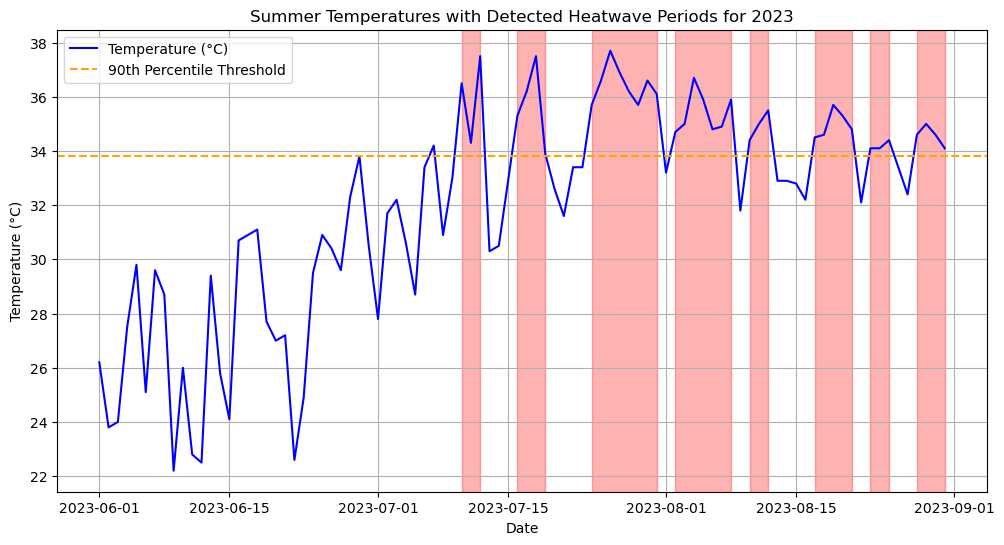

Summary of Detected Summer Heatwave Events for 2023:
         Start        End  Duration
116 2023-07-10 2023-07-12         3
117 2023-07-16 2023-07-19         4
118 2023-07-24 2023-07-31         8
119 2023-08-02 2023-08-08         7
120 2023-08-10 2023-08-12         3
121 2023-08-17 2023-08-21         5
122 2023-08-23 2023-08-25         3
123 2023-08-28 2023-08-31         4


In [17]:
import matplotlib.pyplot as plt

# Define the year you want to plot (e.g., 2023)
year_to_plot = 2023

# Filter the summer data and heatwave summary for the specified year
summer_data_year = summer_data[summer_data.index.year == year_to_plot]
summer_heatwave_summary_year = summer_heatwave_summary[
    (summer_heatwave_summary['Start'].dt.year == year_to_plot)
]

# Plot the summer temperature data for the specified year
plt.figure(figsize=(12, 6))
plt.plot(summer_data_year.index, summer_data_year, label='Temperature (°C)', color='blue')

# Highlight the heatwave periods for the specified year
for _, row in summer_heatwave_summary_year.iterrows():
    start, end = row['Start'], row['End']
    plt.axvspan(start, end, color='red', alpha=0.3, label='Heatwave Period' if _ == 0 else "")

# Plot the heatwave threshold
plt.axhline(y=temp_threshold, color='orange', linestyle='--', linewidth=1.5, label=f'{threshold_percentile}th Percentile Threshold')


# Add labels and legend
plt.title(f'Summer Temperatures with Detected Heatwave Periods for {year_to_plot}')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.grid(True)
plt.show()

# Print the summary for the specified year to compare with the plot
print(f"Summary of Detected Summer Heatwave Events for {year_to_plot}:")
print(summer_heatwave_summary_year)


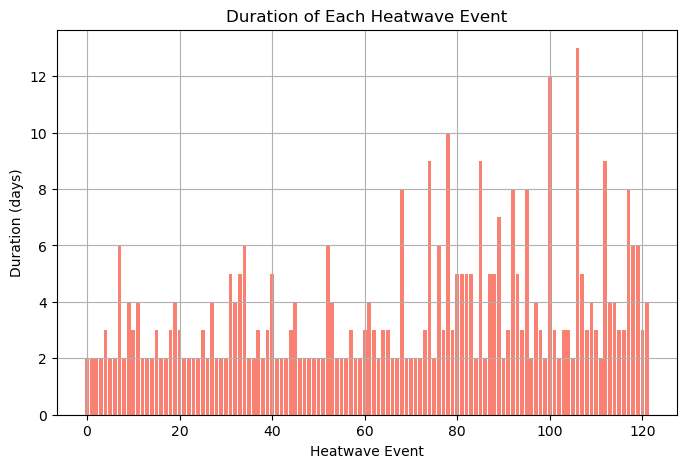

In [42]:
plt.figure(figsize=(8, 5))
plt.bar(summer_heatwave_summary.index, summer_heatwave_summary['Duration'], color='salmon')
plt.xlabel('Heatwave Event')
plt.ylabel('Duration (days)')
plt.title('Duration of Each Heatwave Event')
plt.grid(True)
plt.show()


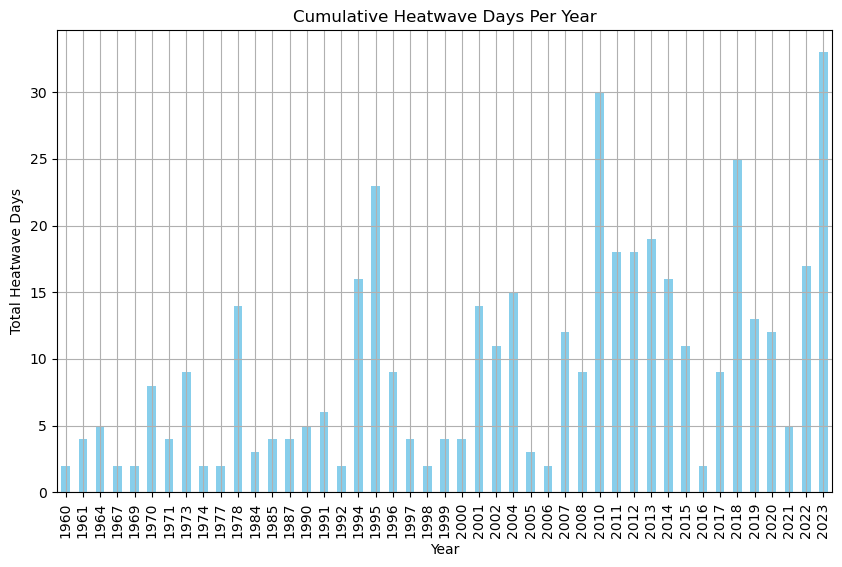

In [43]:
summer_heatwave_summary['Year'] = summer_heatwave_summary['Start'].dt.year
cumulative_days_per_year = summer_heatwave_summary.groupby('Year')['Duration'].sum()

plt.figure(figsize=(10, 6))
cumulative_days_per_year.plot(kind='bar', color='skyblue')
plt.xlabel('Year')
plt.ylabel('Total Heatwave Days')
plt.title('Cumulative Heatwave Days Per Year')
plt.grid(True)
plt.show()


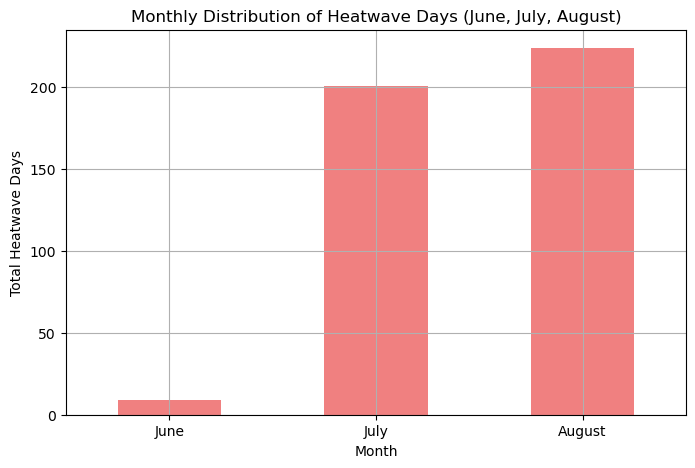

In [44]:
summer_heatwave_summary['Month'] = summer_heatwave_summary['Start'].dt.month
monthly_heatwave_days = summer_heatwave_summary.groupby('Month')['Duration'].sum()

plt.figure(figsize=(8, 5))
monthly_heatwave_days.plot(kind='bar', color='lightcoral')
plt.xlabel('Month')
plt.ylabel('Total Heatwave Days')
plt.title('Monthly Distribution of Heatwave Days (June, July, August)')
plt.xticks(ticks=[0, 1, 2], labels=['June', 'July', 'August'], rotation=0)
plt.grid(True)
plt.show()


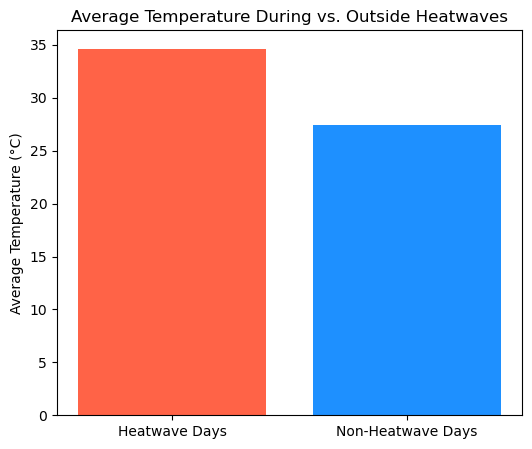

In [45]:
heatwave_days = summer_data.index.isin(summer_heatwave_events.index)
avg_temp_heatwave = summer_data[heatwave_days].mean()
avg_temp_non_heatwave = summer_data[~heatwave_days].mean()

plt.figure(figsize=(6, 5))
plt.bar(['Heatwave Days', 'Non-Heatwave Days'], [avg_temp_heatwave, avg_temp_non_heatwave], color=['tomato', 'dodgerblue'])
plt.ylabel('Average Temperature (°C)')
plt.title('Average Temperature During vs. Outside Heatwaves')
plt.show()


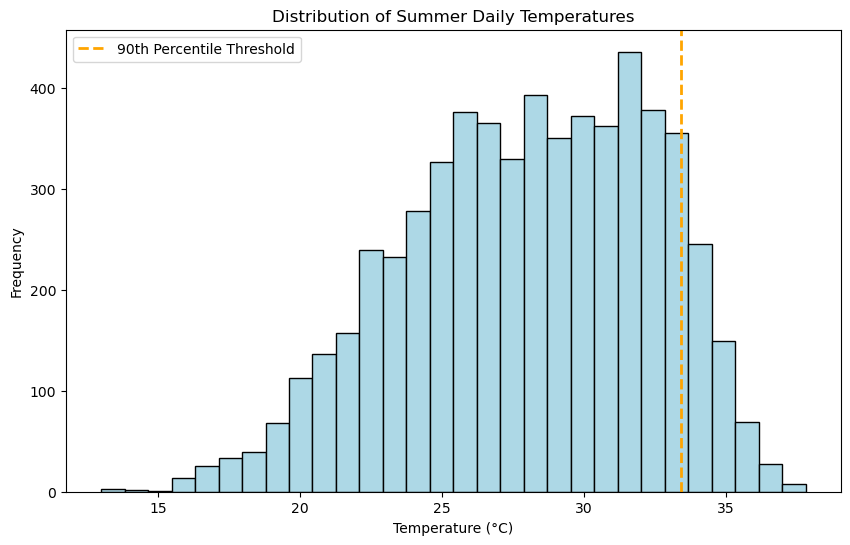

In [46]:
plt.figure(figsize=(10, 6))
plt.hist(summer_data, bins=30, color='lightblue', edgecolor='black')
plt.axvline(temp_threshold, color='orange', linestyle='--', linewidth=2, label=f'{threshold_percentile}th Percentile Threshold')
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Distribution of Summer Daily Temperatures')
plt.legend()
plt.show()


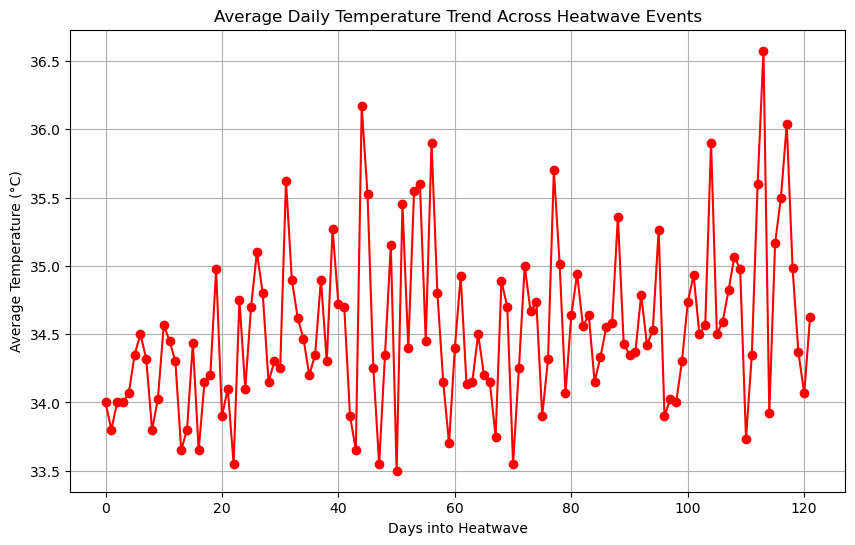

In [47]:
# Calculate average temperature across all heatwave periods for each relative day in the events
daily_trend = []
for _, group in summer_heatwave_summary.iterrows():
    start, end = group['Start'], group['End']
    event_temps = summer_data[start:end].reset_index(drop=True)
    daily_trend.append(event_temps)

# Align data by heatwave duration
max_duration = max([len(trend) for trend in daily_trend])
aligned_temps = pd.DataFrame({i: trend for i, trend in enumerate(daily_trend)}).T.mean(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(aligned_temps, marker='o', color='red')
plt.xlabel('Days into Heatwave')
plt.ylabel('Average Temperature (°C)')
plt.title('Average Daily Temperature Trend Across Heatwave Events')
plt.grid(True)
plt.show()


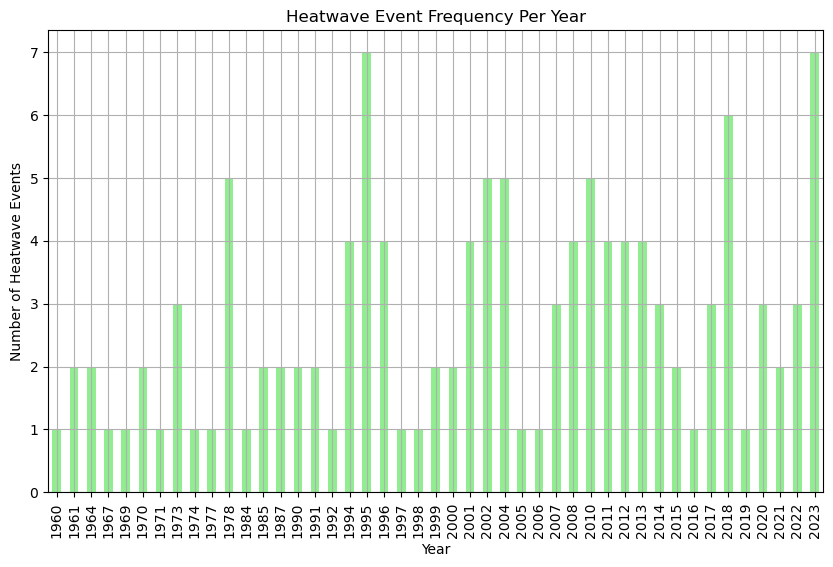

In [48]:
heatwave_events_per_year = summer_heatwave_summary['Year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
heatwave_events_per_year.plot(kind='bar', color='lightgreen')
plt.xlabel('Year')
plt.ylabel('Number of Heatwave Events')
plt.title('Heatwave Event Frequency Per Year')
plt.grid(True)
plt.show()


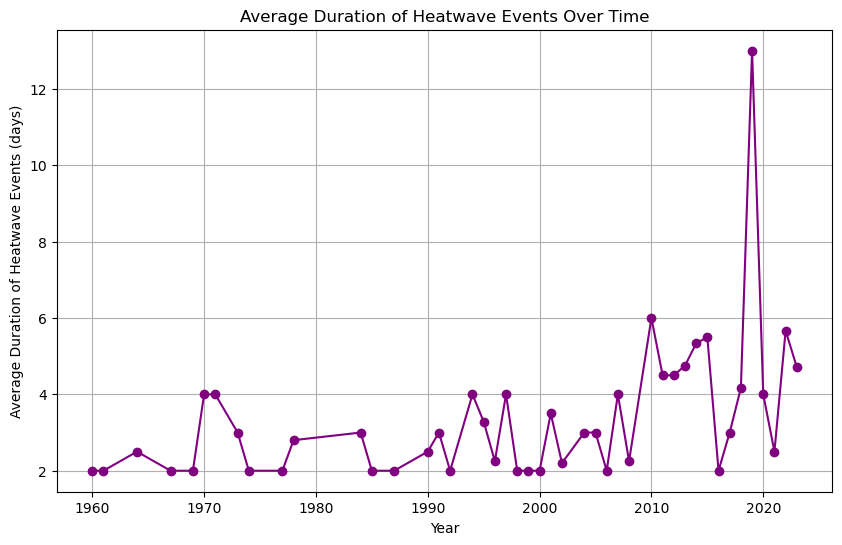

In [49]:
avg_duration_per_year = summer_heatwave_summary.groupby('Year')['Duration'].mean()

plt.figure(figsize=(10, 6))
avg_duration_per_year.plot(kind='line', marker='o', color='purple')
plt.xlabel('Year')
plt.ylabel('Average Duration of Heatwave Events (days)')
plt.title('Average Duration of Heatwave Events Over Time')
plt.grid(True)
plt.show()


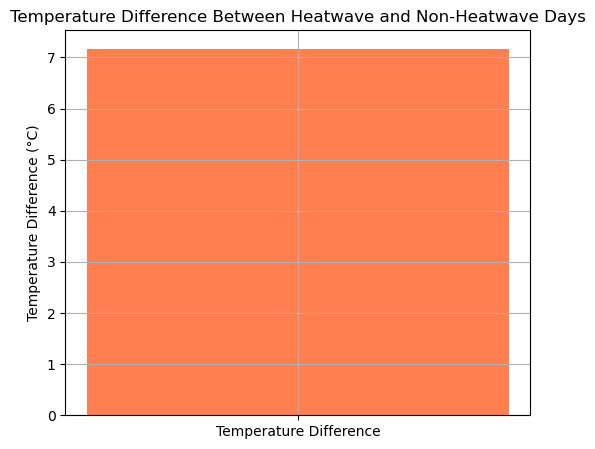

In [50]:
avg_temp_heatwave = summer_data[summer_data.index.isin(summer_heatwave_events.index)].mean()
avg_temp_non_heatwave = summer_data[~summer_data.index.isin(summer_heatwave_events.index)].mean()
temp_difference = avg_temp_heatwave - avg_temp_non_heatwave

plt.figure(figsize=(6, 5))
plt.bar(['Temperature Difference'], [temp_difference], color='coral')
plt.ylabel('Temperature Difference (°C)')
plt.title('Temperature Difference Between Heatwave and Non-Heatwave Days')
plt.grid(True)
plt.show()


In [51]:
import seaborn as sns

# Create DataFrame for heatmap
daily_temps = summer_data.resample('D').mean().unstack()

plt.figure(figsize=(12, 6))
sns.heatmap(daily_temps.values.reshape(-1, 1), cmap='coolwarm', cbar_kws={'label': 'Temperature (°C)'})
for start, end in zip(summer_heatwave_summary['Start'], summer_heatwave_summary['End']):
    plt.axvspan(start, end, color='red', alpha=0.2, label="Heatwave" if start == summer_heatwave_summary['Start'][0] else "")
plt.title("Daily Summer Temperatures with Heatwave Days Highlighted")
plt.show()


ValueError: index must be a MultiIndex to unstack, <class 'pandas.core.indexes.datetimes.DatetimeIndex'> was passed

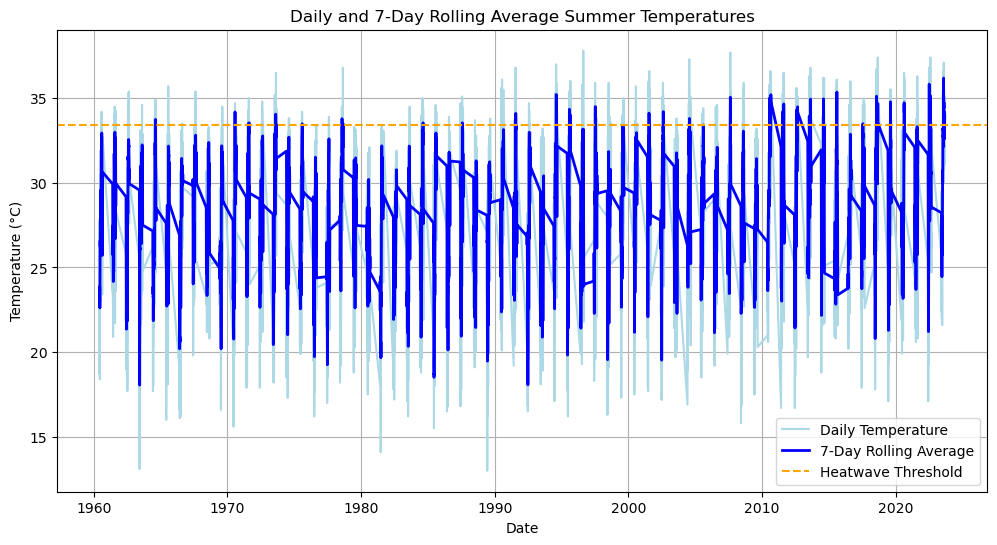

In [52]:
rolling_avg = summer_data.rolling(window=7).mean()

plt.figure(figsize=(12, 6))
plt.plot(summer_data.index, summer_data, label='Daily Temperature', color='lightblue')
plt.plot(rolling_avg.index, rolling_avg, label='7-Day Rolling Average', color='blue', linewidth=2)
plt.axhline(y=temp_threshold, color='orange', linestyle='--', label='Heatwave Threshold')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Daily and 7-Day Rolling Average Summer Temperatures')
plt.legend()
plt.grid(True)
plt.show()


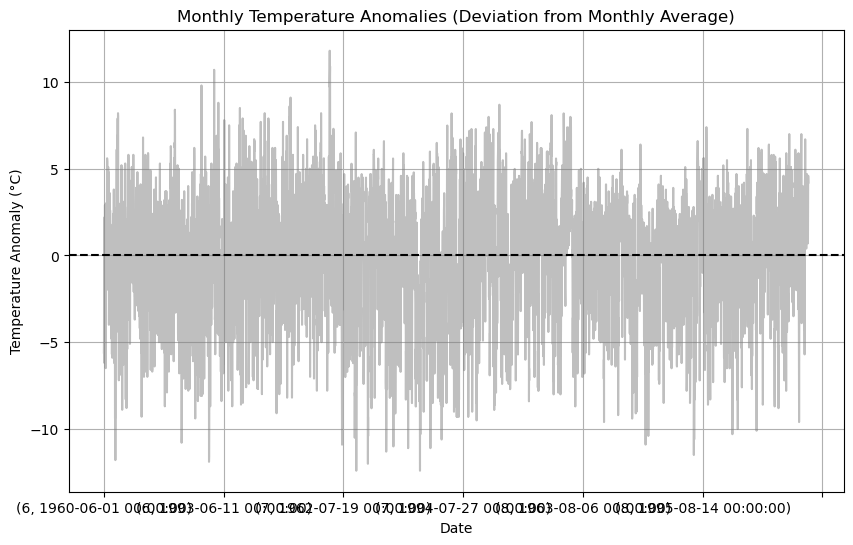

In [53]:
monthly_avg = summer_data.groupby(summer_data.index.month).mean()
monthly_anomalies = summer_data.groupby(summer_data.index.month).apply(lambda x: x - monthly_avg[x.index.month[0]])

plt.figure(figsize=(10, 6))
monthly_anomalies.plot(color='gray', alpha=0.5)
plt.axhline(0, color='black', linestyle='--')
plt.title('Monthly Temperature Anomalies (Deviation from Monthly Average)')
plt.xlabel('Date')
plt.ylabel('Temperature Anomaly (°C)')
plt.grid(True)
plt.show()
